#Luis David Pardo Pedraza

Fictional case study with real data. Main focus of this file is building a Writing style-based Fake news detector and see if with its less computational power expensive model, it can offer comparable results to another model built with the traditional techniques for this type of tasks. The other model can be found in the other file within the carpet where this file is located. The comparative analysis can be found in the README file found also within the same carpet.

#Writing style-based Fake news detector

##Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
import re
import string
from textblob import TextBlob
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize

In [2]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\luisd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

##Data collection

In [3]:
data1 = pd.read_csv(r"C:\Users\luisd\OneDrive\Desktop\Python_projects\Datasets\Datasets_News\Fake.csv")

In [4]:
data2 = pd.read_csv(r"C:\Users\luisd\OneDrive\Desktop\Python_projects\Datasets\Datasets_News\True.csv")

In [5]:
data1["label"] = 1 #Fake news
data2["label"] = 0 #True news

In [6]:
data = pd.concat([data1, data2], axis=0).reset_index(drop=True)

In [7]:
print("Shape of the Dataframe:", data.shape)
data.head()

Shape of the Dataframe: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


##Data cleaning and preprocessing

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


###Missing values

In [9]:
print("Number of missing values:")

data.isna().sum().sum()

Number of missing values:


0

###Duplicates

In [10]:
duplicates = data.duplicated()
duplicated_rows = data[duplicates]
print("Shape of the Dataframe of duplicated rows:", duplicated_rows.shape)

Shape of the Dataframe of duplicated rows: (209, 5)


In [11]:
#Remove duplicate rows
data = data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (44689, 5)


In [12]:
print("Remaining duplicate rows:", data.duplicated().sum())

Remaining duplicate rows: 0


###Remove unnecessary variables

In [13]:
data = data[["title", "text", "label"]]
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44689 entries, 0 to 44688
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   44689 non-null  object
 1   text    44689 non-null  object
 2   label   44689 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.0+ MB
None


###Fake vs True News Distribution

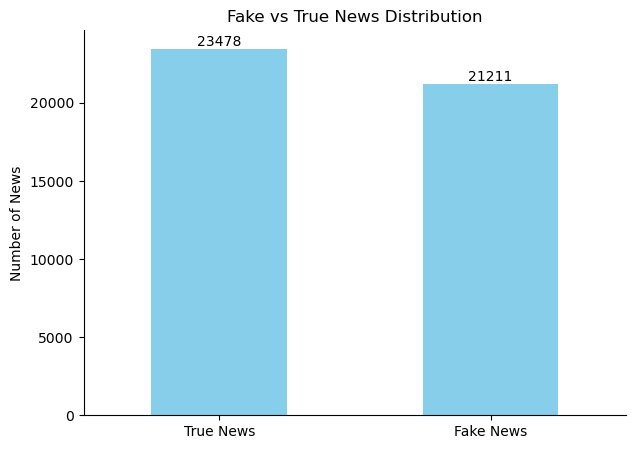

In [14]:
plt.figure(figsize=(7, 5))
value_counts = data["label"].value_counts()

bars = value_counts.plot(kind="bar", color="skyblue")

plt.xticks(ticks=[0, 1], labels=["True News", "Fake News"], rotation=0)

for i, count in enumerate(value_counts):
    plt.text(i, count + 0.5, str(count), ha="center", va="bottom")
    
plt.ylabel("Number of News")
plt.title("Fake vs True News Distribution")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

##Split into train and a temporary sets (further validation and test sets)

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    data[["title", "text"]], data["label"], test_size=0.2, random_state=42, stratify=data["label"]
)
print(f"Training Set: {X_train.shape}, Temporary Set: {X_temp.shape}")

Training Set: (35751, 2), Temporary Set: (8938, 2)


##Feature engineering

###Extraction of writing style features from title and text

####Extracting function definition

In [16]:
def extract_features(df):
    
    #Sentence length (Average words per sentence in text)
    def avg_sentence_length(text):
        sentences = sent_tokenize(text)
        word_counts = [len(word_tokenize(sent)) for sent in sentences if len(word_tokenize(sent)) > 0]
        return np.mean(word_counts) if word_counts else 0

    df["sentence_length_text"] = df["text"].apply(avg_sentence_length)
    df["sentence_length_title"] = df["title"].apply(lambda x: len(word_tokenize(x)) if x else 0)

    #Capitalization Ratio (Percentage of words in ALL CAPS)
    def capital_ratio(text):
        words = word_tokenize(text)
        return sum(1 for word in words if word.isupper()) / len(words) if len(words) > 0 else 0

    df["capital_ratio_text"] = df["text"].apply(capital_ratio)
    df["capital_ratio_title"] = df["title"].apply(capital_ratio)

    #Punctuation frequence and density
    punctuation_marks = ['!', '?', '...']
    def punctuation_density(text):
        return sum(text.count(p) for p in punctuation_marks) / len(text) if len(text) > 0 else 0

    df["punctuation_density_text"] = df["text"].apply(punctuation_density)
    df["punctuation_density_title"] = df["title"].apply(punctuation_density)

    #Sentiment score
    df["sentiment_score_text"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity if x else 0)
    df["sentiment_score_title"] = df["title"].apply(lambda x: TextBlob(x).sentiment.polarity if x else 0)

    return df

####Apply the extracting function on train, validation and test sets

In [17]:
X_train = extract_features(X_train)

In [18]:
X_train.head()

,title,text,sentence_length_text,sentence_length_title,capital_ratio_text,capital_ratio_title,punctuation_density_text,punctuation_density_title,sentiment_score_text,sentiment_score_title
8952,Cops Take Care Of ‘Chronic Problem’–Kill Unar...,"Kevin Matthews, a 35-year-old Black man from D...",25.441176,17,0.006936,0.058824,0.000000,0.000000,0.005886,-0.183333
2462,John McCain: Trump’s Attacks On The Press Are...,Donald Trump has declared the media to be the...,18.300000,20,0.035519,0.050000,0.000582,0.000000,0.019147,0.000000
22269,REDUX 1963? The Deep State vs Donald Trump,Patrick Henningsen 21st Century WireWatching t...,39.051724,9,0.026932,0.111111,0.000386,0.023810,0.041626,0.000000
11168,HAPPY DAY! WATCH NEIL GORSUCH Take Oath Of Off...,Who says President Trump isn t moving on his a...,30.916667,23,0.013477,0.260870,0.002488,0.009804,0.194402,0.800000
4233,LeBron James Has Some CHOICE Words For Trump’...,Ever since the leaked tape of Donald Trump s h...,30.888889,23,0.007194,0.130435,0.000000,0.000000,0.125877,-0.875000


#####Split validation and test sets and apply the extracting function on them

In [19]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [20]:
X_val = extract_features(X_val)
X_test = extract_features(X_test)

###Dataset with writing style features

In [21]:
print(f"Final Dataset Sizes:\nTraining: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Final Dataset Sizes:
Training: (35751, 10), Validation: (4469, 10), Test: (4469, 10)


###Correlation between new features and label (conducted on a copy)

label                        1.000000
sentence_length_title        0.632467
capital_ratio_title          0.491866
punctuation_density_title    0.266097
punctuation_density_text     0.201018
sentence_length_text         0.090946
capital_ratio_text           0.062898
sentiment_score_text         0.027476
sentiment_score_title       -0.037214
Name: label, dtype: float64


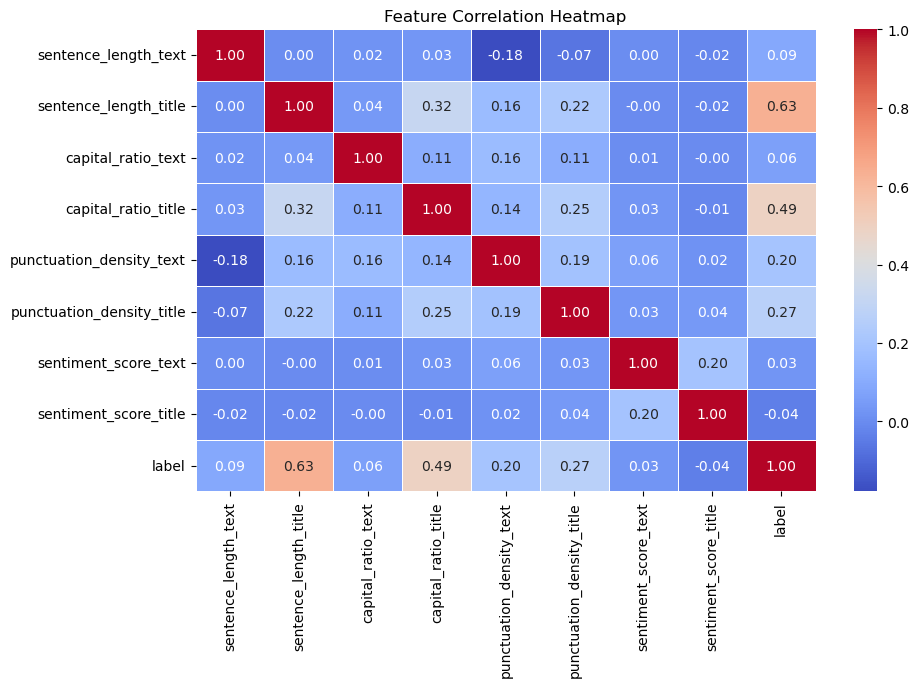

In [22]:
X_train_with_label = X_train.copy()
X_train_with_label["label"] = y_train.values
correlation_matrix = X_train_with_label.corr()
print(correlation_matrix["label"].sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

###Keeping only relevant features for label

In [23]:
selected_features = [
    "sentence_length_title", 
    "capital_ratio_title", 
    "punctuation_density_title", 
    "punctuation_density_text",
    "sentence_length_text"
]

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

###Final dataset for training

In [24]:
print(f"Final Dataset Sizes:\nTraining: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Final Dataset Sizes:
Training: (35751, 5), Validation: (4469, 5), Test: (4469, 5)


####Apply Standard scaler to new writing style features

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

##Model selection

In [26]:
#Models to try
models = {
    "Logistic Regression": LogisticRegression(C=100, penalty="l1", solver="liblinear"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "SVM": SVC(kernel="linear", probability=True)
}

In [27]:
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1")
    cv_results[name] = scores.mean()
    print(f"{name}: F1-score = {scores.mean():.4f}")

sorted_results = sorted(cv_results.items(), key=lambda x: x[1], reverse=True)
print("\nModel Performance Comparison (F1-score):")
for model, score in sorted_results:
    print(f"{model}: {score:.4f}")

Logistic Regression: F1-score = 0.9072
Random Forest: F1-score = 0.9056
XGBoost: F1-score = 0.9197
SVM: F1-score = 0.9078

Model Performance Comparison (F1-score):
XGBoost: 0.9197
SVM: 0.9078
Logistic Regression: 0.9072
Random Forest: 0.9056


##Hyperparameter tuning and cross validation using Randomized Search CV

In [28]:
param_dist = { #Hyperparameter search space
    'n_estimators': [100, 300, 500],  #Number of trees
    'learning_rate': [0.01, 0.1, 0.2],  #Step size
    'max_depth': [3, 6, 9],  #Depth of each tree
    'subsample': [0.7, 0.8, 1.0],  #Percentage of data used per tree
    'colsample_bytree': [0.7, 0.8, 1.0], #Percentage of features used per tree
    'gamma': [0, 0.1, 0.2],  #Minimum loss reduction
    'lambda': [1, 2, 3] #L2 regularization
}

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

#Randomized Search CV
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist, n_iter=20, 
    scoring='f1', cv=5, verbose=2, random_state=42, n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)
print(f"Best Hyperparameters: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Hyperparameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'lambda': 3, 'gamma': 0.2, 'colsample_bytree': 1.0}


##Training and evaluation

###Evaluate on validation set

In [29]:
y_val_pred = best_xgb.predict(X_val_scaled)

In [30]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"Tuned XGBoost Model Performance on Validation Set:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Tuned XGBoost Model Performance on Validation Set:
Accuracy:  0.9279
Precision: 0.9486
Recall:    0.9123
F1-score:  0.9301


###Evaluate on test set

In [31]:
y_test_pred = best_xgb.predict(X_test_scaled)

In [32]:
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"\nFinal Tuned XGBoost Model Performance on Test Set:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


Final Tuned XGBoost Model Performance on Test Set:
Accuracy:  0.9212
Precision: 0.9404
Recall:    0.9076
F1-score:  0.9237


###Calssification Report

In [33]:
y_test_pred_writing = best_xgb.predict(X_test_scaled)

In [34]:
print("\nWriting style-based model (XGBoost) - Classification Report:")
print(classification_report(y_test, y_test_pred_writing))


Writing style-based model (XGBoost) - Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      2121
           1       0.94      0.91      0.92      2348

    accuracy                           0.92      4469
   macro avg       0.92      0.92      0.92      4469
weighted avg       0.92      0.92      0.92      4469



###Confusion matrix

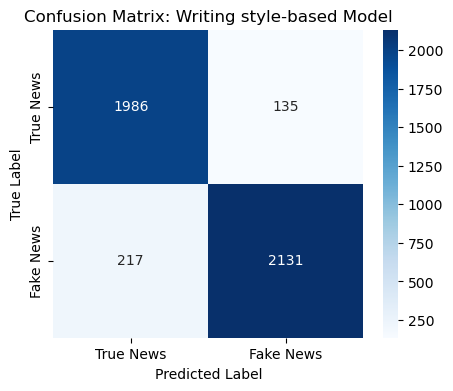

In [35]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["True News", "Fake News"], yticklabels=["True News", "Fake News"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()

plot_confusion_matrix(y_test, y_test_pred_writing, "Writing style-based Model")